# Robustness metrics: defects, Jacobians, Lyapunov spectra, Derrida maps

How does a one-bit perturbation propagate? Evolve a configuration and its
**defect twin** (one node flipped) side by side; the XOR of the two trajectories
is the defect pattern, and its node-mean is the **defect density** — the central
phenotype observable of this project.

In [1]:
import random

import igraph as ig
import matplotlib.pyplot as plt
import numpy as np
import torch as tc

from llna import LLNA
from llna.analysis import (
    calculate_Yt,
    derrida_map_analytical,
    get_derrida_arrays,
    jacobian,
    lyapunov_spectrum,
    lyapunov_spectrum_analytical,
    mean_field_dens_propagation,
)
from llna.networks import create_2d_torus_lattice, watts_strogatz_rewire
from llna.rules import binary_indices, eca_to_llna
from llna.sweep import evolve_defect_pairs

## Defect propagation on a small-world graph

`llna.sweep.evolve_defect_pairs` evolves clean/defected twins for many rules in
lockstep and returns the per-step state and defect densities. Here: the *anneal*
rule $\phi^9_{488,464}$ versus Game of Life on the same graph and soups.

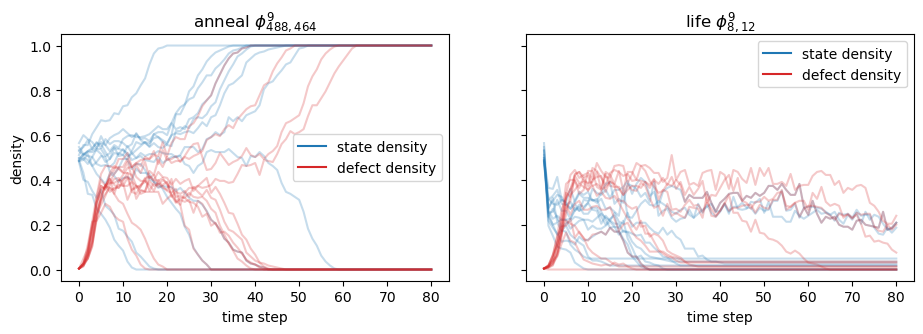

In [2]:
random.seed(3)
graph = watts_strogatz_rewire(create_2d_torus_lattice(15, degree=8), 0.2)
directed = graph.copy(); directed.to_directed()
E = tc.tensor(directed.get_edgelist(), dtype=tc.long).T
N = graph.vcount()

rng = np.random.default_rng(1)
configs = (rng.random((12, N)) < 0.5).astype(np.int64)
defected = configs.copy()
defected[np.arange(12), rng.choice(N, 12, replace=False)] ^= 1

rules = [(488, 464), (8, 12)]  # anneal, life
states, defects = evolve_defect_pairs(E, configs, defected, rules, 9, iso=True, T=80)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.2), sharey=True)
for ax, name, i in zip(axes, ["anneal $\\phi^9_{488,464}$", "life $\\phi^9_{8,12}$"], range(2)):
    ax.plot(states[i].T, color="tab:blue", alpha=0.25)
    ax.plot(defects[i].T, color="tab:red", alpha=0.25)
    ax.plot([], [], color="tab:blue", label="state density")
    ax.plot([], [], color="tab:red", label="defect density")
    ax.set_title(name), ax.set_xlabel("time step"), ax.legend()
axes[0].set_ylabel("density");

## The Boolean Jacobian

$J_{ij} = 1$ iff flipping node $j$ now changes node $i$ at the next step —
a Boolean derivative, computed by batching all $N$ single-defect twins through
one step. For the parity rule (XOR), every input always matters:
$J = A + I$ exactly, independent of the state.

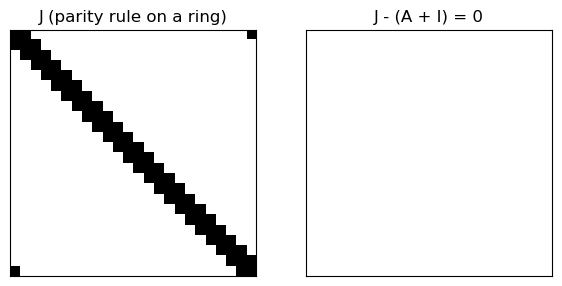

In [3]:
ring = ig.Graph.Ring(24, circular=True)
b_set, s_set = eca_to_llna(150)
parity = LLNA(3, b_set, s_set, iso=False)
state = np.random.default_rng(5).integers(0, 2, 24)
J = jacobian(ring, parity, state)

fig, axes = plt.subplots(1, 2, figsize=(7, 3.2))
axes[0].imshow(J, cmap="Greys"), axes[0].set_title("J (parity rule on a ring)")
A = np.array(ring.get_adjacency().data)
axes[1].imshow(J - (A + np.eye(24, dtype=int)), cmap="Greys", vmin=0, vmax=1)
axes[1].set_title("J - (A + I) = 0")
for ax in axes:
    ax.set_xticks([]), ax.set_yticks([])

## Lyapunov spectra in tangent space

Propagate the unit defect sphere with the Jacobian product
$Y_T = J_{T-1} \cdots J_1 J_0$ (in float64, **no** mod 2 — counting defect
*paths*, not parities) and read off exponents from the singular values:
$\lambda_i = \log(\sigma_i) / T$.

Rules with a *constant* Jacobian admit a closed form via circulant matrices.
For ECA 150 the spectrum is $\log|1 + 2\cos(2\pi k/N)|$ — the numerical
pipeline reproduces it to machine precision, which is the benchmark anchoring the
CSF submission (see `csf-submission/`).

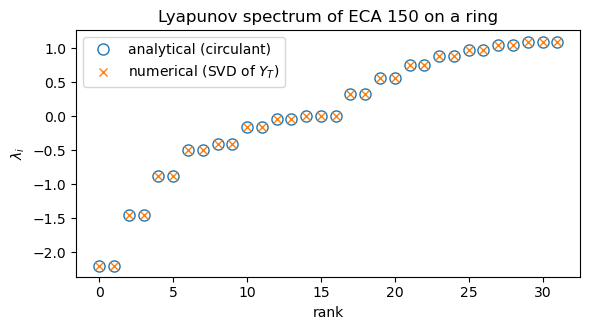

In [4]:
N_ring, T = 32, 6
ring = ig.Graph.Ring(N_ring, circular=True)
state = np.random.default_rng(3).integers(0, 2, N_ring)
Yt = calculate_Yt(ring, parity, state, T=T)
with np.errstate(divide="ignore"):
    numerical = np.sort(lyapunov_spectrum(Yt, T=T))
analytical = np.sort(lyapunov_spectrum_analytical(150, N_ring))

plt.figure(figsize=(6.5, 3.2))
plt.plot(analytical, "o", ms=8, mfc="none", label="analytical (circulant)")
plt.plot(numerical[np.isfinite(numerical)], "x", ms=6, label="numerical (SVD of $Y_T$)")
plt.xlabel("rank"), plt.ylabel("$\\lambda_i$"), plt.legend()
plt.title("Lyapunov spectrum of ECA 150 on a ring");

## Derrida maps and mean-field theory

The **Derrida map** sends today's defect density to tomorrow's: measure it by
XOR-ing perturbed pairs (dots), or compute it analytically from the rule's
combinatorics (line). Slope at the origin > 1 means chaotic defect growth.
The **mean-field map** does the same for the state density itself.

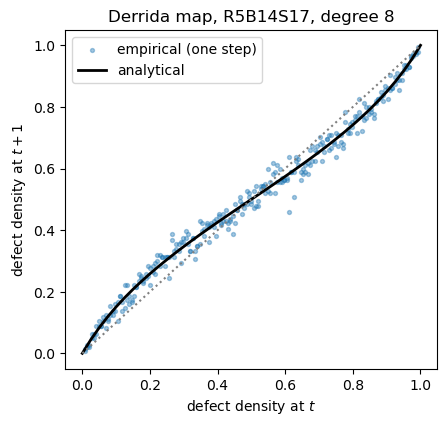

In [5]:
torus = create_2d_torus_lattice(12, degree=8)
model = LLNA(5, [1, 2, 3], [0, 4], iso=True)
np.random.seed(4)
inputs, outputs = get_derrida_arrays(torus, model, points_per_rho=2)

delta_grid = np.linspace(0, 1, 41)
analytical_map = np.array(
    [derrida_map_analytical(5, [1, 2, 3], [0, 4], d, 8, iso=True) for d in delta_grid]
).squeeze()

plt.figure(figsize=(4.8, 4.4))
plt.scatter(inputs, outputs, s=8, alpha=0.4, label="empirical (one step)")
plt.plot(delta_grid, analytical_map, "k", lw=2, label="analytical")
plt.plot([0, 1], [0, 1], ":", color="grey")
plt.xlabel("defect density at $t$"), plt.ylabel("defect density at $t+1$")
plt.legend(), plt.title(f"Derrida map, {model}, degree 8");

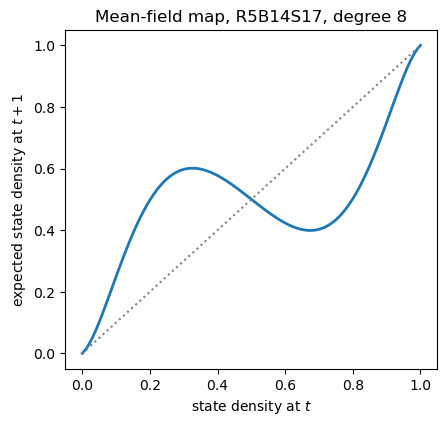

In [6]:
dens = np.linspace(0, 1, 101)
plt.figure(figsize=(4.8, 4.4))
plt.plot(dens, mean_field_dens_propagation(5, [1, 2, 3], [0, 4], dens, 8), lw=2)
plt.plot([0, 1], [0, 1], ":", color="grey")
plt.xlabel("state density at $t$"), plt.ylabel("expected state density at $t+1$")
plt.title(f"Mean-field map, {model}, degree 8");

## Scaling up: `llna sweep`

Sweeping *all* non-equivalent rules over graph ensembles is a shell one-liner —
batched over rules, seeded end-to-end, and resumable (interrupt it and re-run the
same command; it continues from the last completed chunk):

```bash
llna sweep --network-type random --resolution 5 --L 30 --T 100 \
           --num-graphs 30 --num-init-conf 30 --seed 42 \
           --output data/results/regenerated_2026/results_random.h5
```

Results carry their provenance (parameters, seed, git commit) as HDF5
attributes. If a results file is present, the cell below reproduces the
manuscript's key visual: converged state density vs defect density per rule.

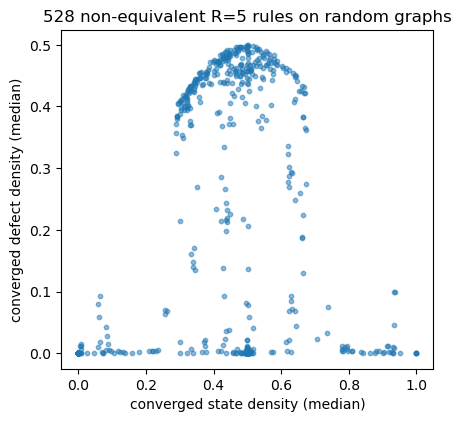

In [7]:
import h5py
from pathlib import Path

results = Path("../data/results/results_random.h5")
if results.exists():
    with h5py.File(results) as f:
        grp = f["resolution5/random"]
        state, defect = grp["state/median"][...], grp["defect/median"][...]
    plt.figure(figsize=(4.8, 4.4))
    plt.scatter(state, defect, s=10, alpha=0.5)
    plt.xlabel("converged state density (median)")
    plt.ylabel("converged defect density (median)")
    plt.title("528 non-equivalent R=5 rules on random graphs")
else:
    print("no results file at", results)